In [45]:
import numpy as np 
import matplotlib.pyplot as plt


In [81]:
# GENERATE SYNTHETIC DATA - FIRST : enable reproducity
np.random.seed(42)
# In practice we will load the data frame here
def generate_dataset(n_normal=300, n_nomaly=20, seed=42):
    rng=np.random.RandomState(seed)
    cluster_a=rng.multivariate_normal(
        mean=[0.5, 0.0],
        cov=[[1.2, 0.5], [0.5, 0.9]],
        size=int(n_normal * 0.55)
    )

    cluster_b=rng.multivariate_normal(
        mean=[5.0, 4.0],
        cov=[[0.9, -0.4], [-0.4, 1.1]],
        size=int(n_normal*0.45)
    )
    x_anom_raw=rng.uniform(low=[-5, -5], high=[9,9], size=(200, 2))
    print(cluster_b.shape)
    x_normal=np.vstack([cluster_a, cluster_b])
    print(x_normal)
    print(f"printing cluster_a: {cluster_a}")
    return cluster_a, cluster_b, x_anom_raw

(135, 2)
[[ 0.06031915 -0.45236008]
 [-0.81212625  0.40312479]
 [ 0.83709416  0.0387538 ]
 [-1.42142506 -0.73454418]
 [ 0.73691871  0.66766386]
 [ 1.16816682  0.07533164]
 [ 1.08648216 -1.29647058]
 [ 2.47901038  0.96318839]
 [ 1.38251898  0.9412306 ]
 [ 2.0259748  -0.14373178]
 [-0.87638898 -1.22855804]
 [ 1.05004971 -0.88112076]
 [ 0.99949072  0.47209745]
 [ 1.49484476  1.08045946]
 [ 1.23071226  0.27948935]
 [ 0.30184946  1.5301525 ]
 [ 0.97235386 -0.60650832]
 [ 0.2021244  -1.32732968]
 [ 1.139898   -1.29874223]
 [ 1.75065491  1.10882007]
 [-0.31716486 -0.45278983]
 [ 0.74693457 -0.08897854]
 [ 2.29949648  0.68692766]
 [ 0.50484208  0.96102354]
 [ 0.91905895 -1.28496823]
 [ 0.34102652 -0.4670448 ]
 [ 0.91561459  0.86321669]
 [-0.94103611 -0.22872759]
 [ 1.47830094  0.44783654]
 [-0.2563607   0.3207821 ]
 [ 1.06253728  0.25039622]
 [ 2.13172772  0.13066775]
 [-0.90559433  0.18252246]
 [ 0.13715873  0.63892075]
 [ 0.41604229 -0.64674309]
 [-0.53064894  0.62614391]
 [-0.14261836  0.93

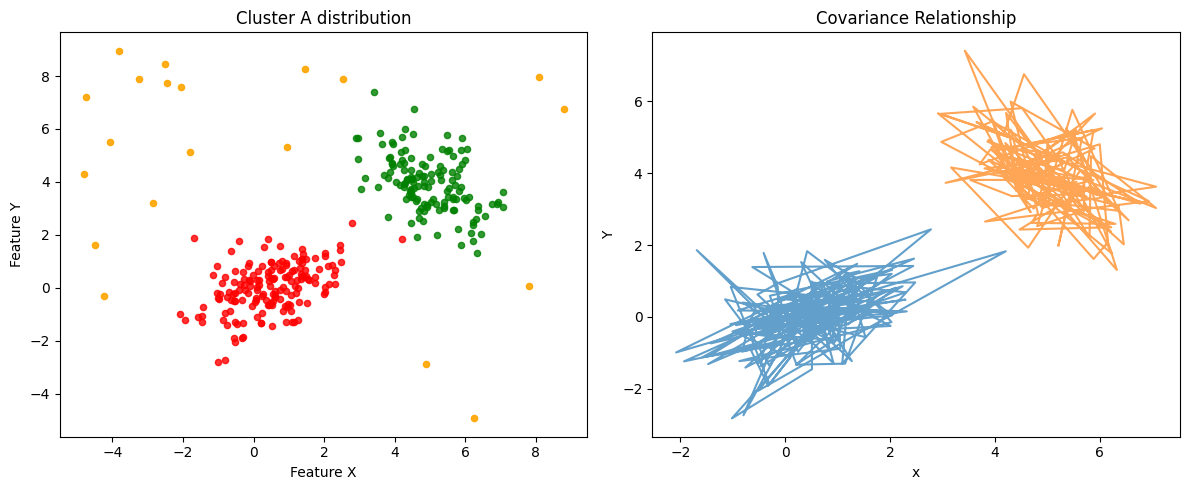

In [84]:
cluster_a, cluster_b, x_anom_raw=generate_dataset()
def visualize_cluster_a(cluster_a=cluster_a, cluster_b=cluster_b, x_anom_raw=x_anom_raw, n_normaly=20):
     # filter out accidental anmalies near the cluster
    dists=np.minimum(
        np.linalg.norm(x_anom_raw - [0,0], axis=1),
        np.linalg.norm(x_anom_raw  -[5,4], axis=1)
    )
    x_anomaly=x_anom_raw[dists > 4.0][:n_normaly]
 
    # print(x_anom)
    x1=cluster_a[:, 0]
    y1=cluster_a[:, 1]
    x2=cluster_b[:, 0]
    y2=cluster_b[:, 1]
    x3=x_anomaly[:,0]
    y3=x_anomaly[:, 1]

   
    # create subplot
    fig, axes=plt.subplots(1, 2, figsize=(12, 5))
    # Plot 1: Actual cluster
    axes[0].scatter(x1, y1, alpha=0.8, s=20, color="REd")
    axes[0].set_title("Cluster A distribution")
    axes[0].set_xlabel("Feature X")
    axes[0].set_ylabel("Feature Y")
    axes[0].scatter(x2, y2, alpha=0.8, s=20, color="green")
    axes[0].scatter(x3, y3, alpha=0.9, s=20, color="orange")

    # PLOT 2: X vs Y relationship
    axes[1].plot(x1, y1, '-', alpha=0.7)
    axes[1].plot(x2, y2, '-', alpha=0.7)
    axes[1].set_title("Covariance Relationship")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("Y")
    plt.tight_layout()
    plt.show()
visualize_cluster_a()
    

In [ ]:
cluster_a, cluster_b=generate_dataset()

def generating_anomaly_candidate(cluster_a=cluster_a, cluster_b=cluster_b):
    
    
    
    